# Lista prática I

**Instruções gerais:** Sua submissão deve conter: 
1. Um "ipynb" com seu código e as soluções dos problemas
2. Uma versão pdf do ipynp

## Vizinhos mais próximos

**Exercício 1.** O código abaixo carrega o dataset MNIST, que consiste em imagens de dígitos entre $0$ e $9$. Teste o $k$-NN com distância euclidiana para classificação do conjunto de teste. Use valores de $k$ diferentes (e.g., de 1 a 5) e reporte a acurácia para cada valor de $k$. Lembre que a acurácia é o percentual de amostras classificadas corretamente. Notavelmente, as entradas do MNIST tem dimensão relativamente alta (64). Plote uma imagem com a variância amostral dos pixels das imagens e comente. Também mostre as imagens classificadas de maneira errônea e comente.

In [11]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split


SEED = 42
np.random.seed(SEED)

@dataclass
class Dataset:
    features_train: np.ndarray 
    features_test: np.ndarray  
    labels_train: np.ndarray   
    labels_test: np.ndarray

# Import dataset and separate train/test subsets
mnist = Dataset(*train_test_split(
    *load_digits(return_X_y=True),
    random_state=SEED,
))

print(mnist.features_train.shape, mnist.labels_train.shape)


(1347, 64) (1347,)


Acurácia para k=1: 0.9822
Acurácia para k=2: 0.9844
Acurácia para k=3: 0.9867
Acurácia para k=4: 0.9867
Acurácia para k=5: 0.9933


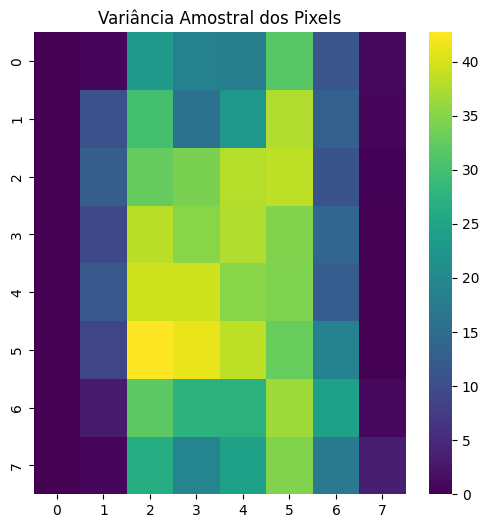

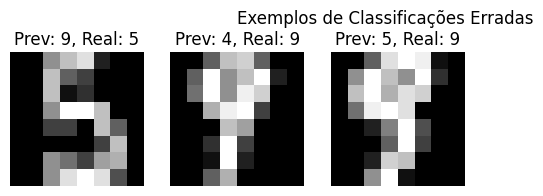

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# Avaliação do k-NN para diferentes valores de k
k_values = range(1, 6)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(mnist.features_train, mnist.labels_train)
    predictions = knn.predict(mnist.features_test)
    acc = accuracy_score(mnist.labels_test, predictions)
    accuracies.append(acc)
    print(f"Acurácia para k={k}: {acc:.4f}")

# Plot da variância amostral dos pixels
variance = np.var(mnist.features_train, axis=0).reshape(8, 8)
plt.figure(figsize=(6, 6))
sns.heatmap(variance, cmap='viridis', annot=False)
plt.title("Variância Amostral dos Pixels")
plt.show()

# Identificar e exibir imagens classificadas erroneamente
misclassified_idxs = np.where(predictions != labels_test)[0]
num_errors = min(len(misclassified_idxs), 10)

plt.figure(figsize=(10, 4))
for i, idx in enumerate(misclassified_idxs[:num_errors]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(features_test[idx].reshape(8, 8), cmap='gray')
    plt.title(f"Prev: {predictions[idx]}, Real: {labels_test[idx]}")
    plt.axis("off")

plt.suptitle("Exemplos de Classificações Erradas")
plt.show()


O gráfico da variância amostral dos piixels mostra a parte central do heatmap bem clara,indicando variancias maiores, enquanto que as partes laterais estão mais escuras. Isso faz sentido pois há uma grande variedade de números apresentados na região central, difernte da parte lateral. Além disso, o modelo usando k = 5 mostrou maior acurácias entre os modelos, errando em classificar apenas 3 imagens.

**Exercício 02.** O código abaixo carrega o dataset "two moons", que consiste de amostras bidimensionais divididas em duas classes. Teste o $k$-NN com distância euclidiana para classificação do conjunto de teste. Use valores de $k$ diferentes (e.g., de 1 a 10). Plote a superfície de decisão para cada valor de $k$. Como $k$ influencia na suavidade dessas superfícies?

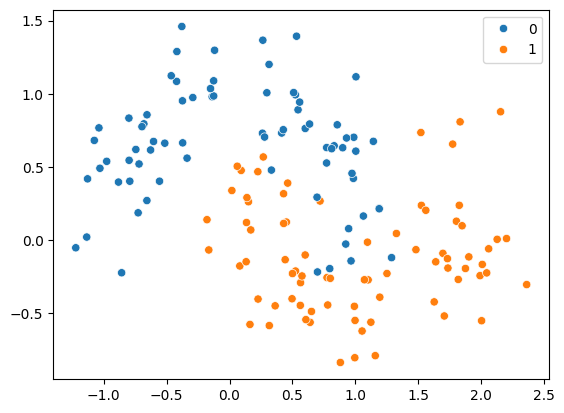

In [23]:
# Import dataset and separate train/test subsets
moon = Dataset(*train_test_split(
    *make_moons(n_samples=200, shuffle=True, noise=0.25, random_state=SEED),
    random_state=SEED,
))

# Let's also plot the moon dataset, for you to take a look at it.
sns.scatterplot(
    x=moon.features_train[:, 0],
    y=moon.features_train[:, 1],
    hue=moon.labels_train,
)
plt.show()

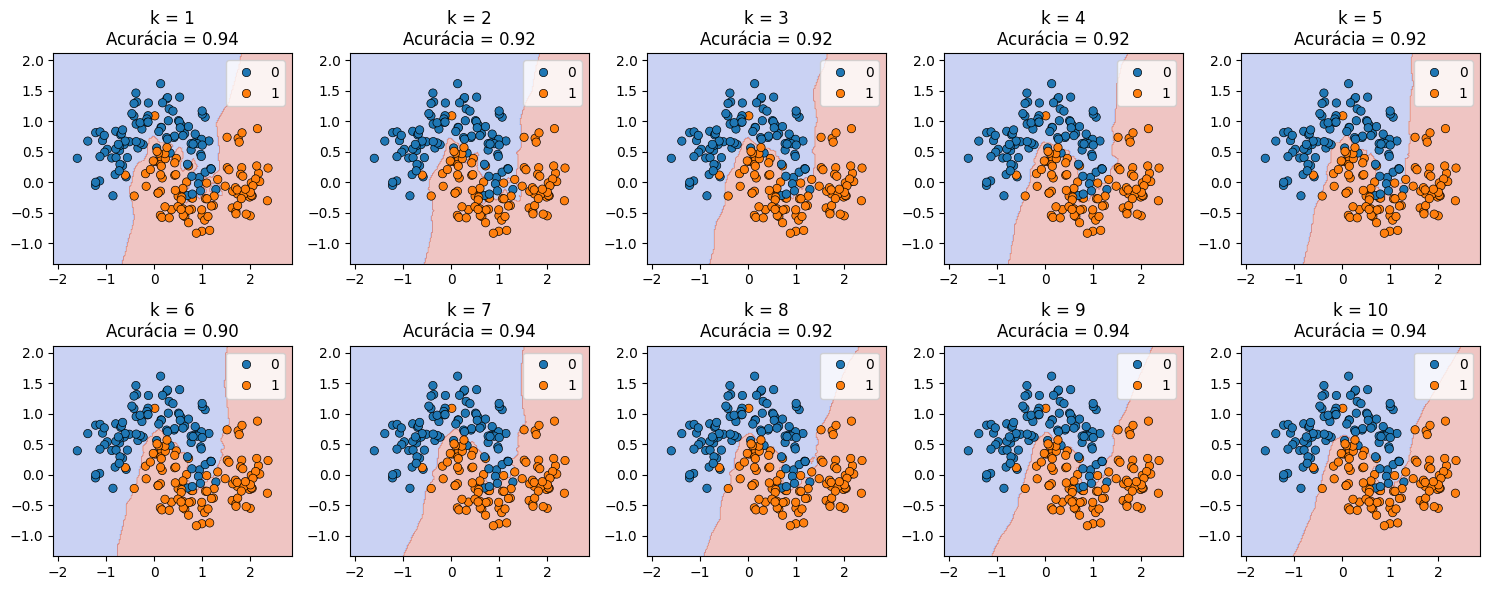

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score

# Configuração
SEED = 42
np.random.seed(SEED)

# Carregar dataset Two Moons
features, labels = make_moons(n_samples=200, shuffle=True, noise=0.25, random_state=SEED)
features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, random_state=SEED
)

# Visualizar os dados
def plot_decision_boundary(knn, X, y, ax, accuracy):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, edgecolor='k', ax=ax)
    ax.set_title(f"k = {knn.n_neighbors}\nAcurácia = {accuracy:.2f}")

# Testar k-NN para diferentes valores de k
k_values = range(1, 11)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(features_train, labels_train)
    predictions = knn.predict(features_test)
    acc = accuracy_score(labels_test, predictions)
    plot_decision_boundary(knn, features, labels, axes[i], acc)

plt.tight_layout()
plt.show()


Podemos notar que para valores pequenos de k como 1 e 2, a fronteira de decisão é bem irregular. Conforme k aumenta, a superfície se suaviza permitindo melhor generalização, como ocorre em valores intermediários como k = 5 ou k = 6. Já para valores maiores como k = 10 a superfície se torna ainda mais suave, tornando possível a perda de detalhes importantes dod dados.

# Regressão linear

**Exercício 1.** Deixamos à sua disposição o dataset ["California Housing"](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing), dividio em treino, teste e validação.
O modelo que você utilizará para aproximar a relação funcional entre as features e as labels é o modelo linear, i.e., $\mathbf{y} = X\theta$.
Entretanto, você deve estimar seus parâmetros (minimizando o *mean squared error*) com **dois algoritmos diferentes**.
Uma implementação deve estimar $\theta$ por meio de **Stochastic Gradient Descent (SGD)** e, a outra, por meio de **Ordinary Least Squares (OLS)**, ou seja, utilizar a solução em fórmula fechada vista em aula.

Para o SGD, o ponto inicial deve ser escolhido aleatoriamente e o algoritmo deve parar quando a norma da diferença entre duas estimativas consecutivas de $\theta$ for menor do que um $\varepsilon > 0$ previamente especificado.
Para o experimento a seguir, fixe $\varepsilon$ em um valor pequeno (por exemplo, alguma potência de $1/10$) para a qual o algoritmo convirja no máximo em alguns minutos para uma solução com perda pequena.

Para diferentes tamanhos de minibatch (por exemplo $\{2^{j}: 1 \leq j \leq 7\}$), plote um gráfico representando o valor da perda $ L(\hat{\theta}) = \frac{1}{n} \lVert X \hat{\theta} - \mathbf{y} \rVert^{2}$ no conjunto de validação em função do número de epochs. Mostre também o valor ótimo obtido com OLS. Comente os resultados e o efeito tamanho do mini-batch, e.g., no tempo de treinamento. Reporte valores nos conjuntos de treino, validação e teste.

In [2]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)


features, labels = fetch_california_housing(return_X_y=True)
features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.25
)

features_train, features_validation, labels_train, labels_validation = train_test_split(
    features_train, labels_train, test_size=0.25
)

MSE: 1.5037837481934173
MSE: 1.4633838334540954


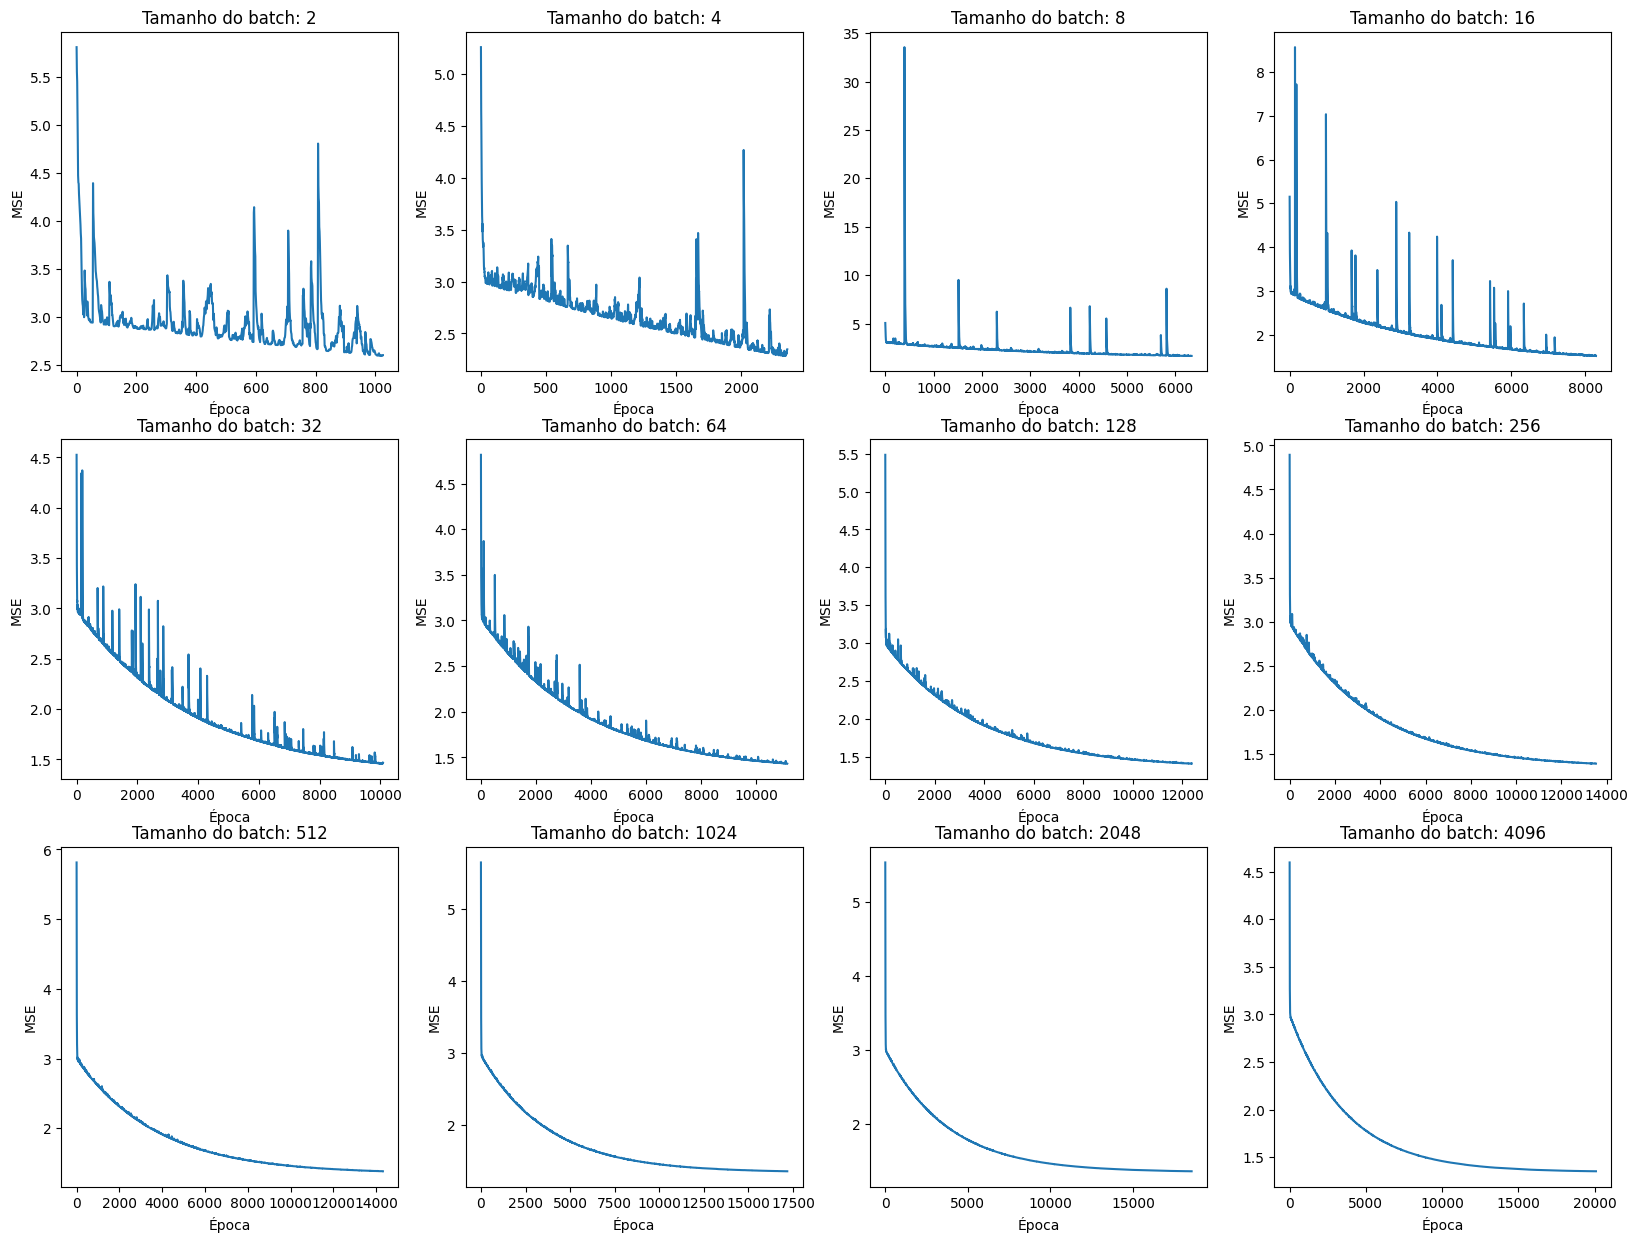

In [3]:
class LinearRegression():  # utilizando y = X.dot(theta)
    
    def __init__(self, learning_rate=1e-8, batch_size=32, optimization="SGD", epsilon=1e-7):
        self.theta = None
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.optimization = optimization
        self.epsilon = epsilon
        
    def fit(self, features, labels):  # features: X (n_amostras, n_features), labels: y (n_amostras, 1)
        self.features = features
        self.labels = labels
        
        if self.optimization == "SGD":  # Stochastic Gradient Descent (Descentimento Estocástico do Gradiente)
            
            # adicionar o viés (bias) à matriz de características
            features = np.hstack((np.ones((features.shape[0], 1)), features))
            
            # inicializar theta com valores aleatórios
            self.theta = np.random.normal(scale = 1e-4, size = (features.shape[1], 1))
            
            labels = self.labels.reshape(-1, 1)
            
            epoch = 0
            self.thetas = []  # lista para armazenar os valores de theta durante as iterações
            
            while True:
                
                # embaralhar os dados, pegando uma amostra aleatória do tamanho batch_size
                idx = np.random.choice(features.shape[0], self.batch_size)
                features_batch = features[idx]
                labels_batch = labels[idx]
                
                # calcular o gradiente
                gradient = 2 * features_batch.T.dot(features_batch.dot(self.theta) - labels_batch) / self.batch_size
                
                # guardar o valor de theta anterior
                theta_old = self.theta
                        
                # atualizar o theta usando o gradiente
                self.theta = self.theta - self.learning_rate * gradient
                self.thetas.append(self.theta)
                
                epoch = epoch + 1
                
                # terminar o loop quando a norma da diferença entre dois valores consecutivos de theta for menor que epsilon
                if np.linalg.norm(self.theta - theta_old) < self.epsilon:
                    break
            
        elif self.optimization == "OLS":  # Ordinary Least Squares (Mínimos Quadrados Ordinários)
            # adicionar o viés (bias) à matriz de características
            features = np.hstack((np.ones((features.shape[0], 1)), features))
            
            # X^T * X * theta = X^T * y => theta = (X^T * X)^-1 * X^T * y
            self.theta = np.linalg.inv(features.T.dot(features)).dot(features.T).dot(self.labels)
        
    def predict(self, features):
        # adicionar o viés (bias) à matriz de características
        features = np.hstack((np.ones((features.shape[0], 1)), features))
        return features.dot(self.theta)

# Criando e treinando o modelo usando SGD
SGD = LinearRegression(optimization="SGD")
SGD.fit(features_train, labels_train)

# Fazendo previsões e calculando o MSE para o conjunto de validação
pred_validation = SGD.predict(features_validation)
print('MSE:', np.mean((pred_validation - labels_validation.reshape(-1, 1)) ** 2))

# Fazendo previsões e calculando o MSE para o conjunto de teste
pred_test = SGD.predict(features_test)
print('MSE:', np.mean((pred_test - labels_test.reshape(-1, 1)) ** 2))

# Criando um gráfico para visualizar os erros quadráticos para diferentes tamanhos de batch
import matplotlib.pyplot as plt

f = plt.figure(figsize=(20, 15))

# Experimentando com diferentes tamanhos de batch
for i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
    model = LinearRegression(optimization="SGD", batch_size=2**i)
    model.fit(features_train, labels_train)
    
    squared_errors = []
    
    X_validation = np.hstack((np.ones((features_validation.shape[0], 1)), features_validation))
    
    # Usando os pesos armazenados na lista thetas (treinados com o conjunto de treinamento) para calcular o erro no conjunto de validação
    for j in range(len(model.thetas)):
        error = np.mean((X_validation.dot(model.thetas[j]) - labels_validation.reshape(-1, 1)) ** 2)
        squared_errors.append(error)
    
    # Adicionando subgráficos para visualizar o MSE em cada época
    ax = f.add_subplot(3, 4, i)
    ax.plot(squared_errors)
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE')
    ax.set_title(f'Tamanho do batch: {2**i}')


De maneira geral conforme o número de iterações aumenta, o MSE diminui. A respeito do efeito do tamanho do batch no MSE, conforme o tamanho do batch aumenta, a curva do MSE se torna mais suave, indicando que o modelo está convergindo de maneira mais estável. Isso ocorre porque, com batches maiores, o gradiente é calculado a partir de uma maior quantidade de dados, o que resulta em uma atualização de parâmetros mais precisa e menos suscetível a variações. Já para o tempo de treinamento, observamos que com o aumento do tamanho do batch, o tempo de cada iteração também tende a aumentar, pois o modelo processa uma quantidade maior de dados por vez. Isso pode resultar em um maior tempo total de treinamento, mesmo que o número total de iterações diminua.

In [17]:
OLS = LinearRegression(optimization="OLS")
OLS.fit(features_train, labels_train)

theta = OLS.theta

X_validation = np.hstack((np.ones((features_validation.shape[0], 1)), features_validation))

print('MSE:', np.mean((X_validation.dot(theta) - labels_validation.reshape(-1, 1)) ** 2))

MSE: 2.204958087295249


O método SGD obteve menores valores para o MSE do que o método OLS.

**Exercício 2.** Agora, você deve implementar uma **Rede RBF** com função de base Gaussiana (veja as notas de aula).
Para os centróides, utilize o output de um modelo de clusterização por K médias, por meio da função que disponibilizamos, como a seguir:

In [18]:
def k_means_factory(n_clusters: int) -> KMeans:
    return KMeans(n_clusters=n_clusters, n_init="auto")

k_means_model = k_means_factory(n_clusters=2)
dumb_data = np.array(
    [[1, 2],
     [1, 4],
     [1, 0],
     [10, 2],
     [10, 4],
     [10, 0]]
)
k_means_model.fit(dumb_data)
cluster_centers = k_means_model.cluster_centers_
print(cluster_centers) # Shape (n_clusters, n_features)

[[ 1.  2.]
 [10.  2.]]


Para determinar o melhor valor de $k$ para o algoritmo de clusterização, treine o modelo (usando a fórmula de OLS) com diferentes valores e escolha o que possuir o menor erro de validação. Faça um gráfico mostrando o valor do erro de validação para diferentes valores de $k$. Mostre também a performance do modelo escolhido no conjunto de teste. Compare com o modelo linear simples da questão anterior. Discuta os resultados.

Para definir o valor do hiper-parâmetro $\gamma$, use a seguinte heurística --- que pode ser achado no livro "Neural Networks", por Simon Haykin:

$$
\gamma = \frac{1}{d_\text{max}^2},
$$

onde $d_\text{max}$ é a maior distância entre um par de centróides. Note que o valor costuma mudar para $k$'s diferentes.


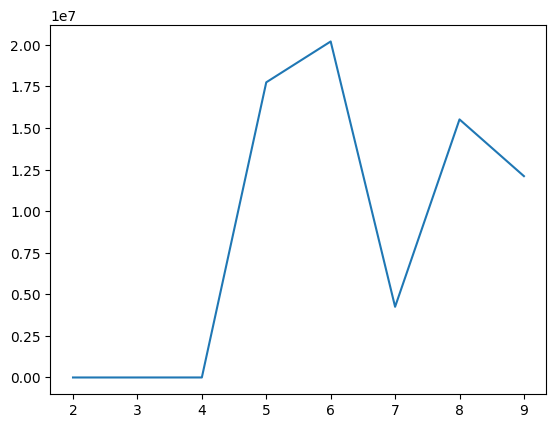

In [19]:
# Função de base radial (RBF)
def rbf_func(x, c, max_distance):
    # O parâmetro gamma é calculado com base na distância máxima entre os centros dos clusters
    gamma = 1 / ((max_distance ** 2))
    # c é o centro do cluster
    return np.exp((-np.linalg.norm(x - c) ** 2) * gamma)

# Classe que implementa uma Rede de Função de Base Radial (RBF)
class RBF():
    
    def __init__(self, n_clusters=2):
        # Inicializa a classe com o número de clusters (centros de RBF)
        self.n_clusters = n_clusters
        
    def fit(self, features, labels):
        # Método para treinar o modelo RBF
        
        self.features = features
        self.labels = labels
        
        # Encontrar os centros usando o K-means
        k_means_model = k_means_factory(n_clusters=self.n_clusters)
        k_means_model.fit(features)
        cluster_centers = k_means_model.cluster_centers_
        
        # Calcular a distância máxima entre os centros dos clusters
        self.max_distance = np.max([np.linalg.norm(cluster_centers[i] - cluster_centers[j]) 
                                    for i in range(self.n_clusters) for j in range(self.n_clusters)])
        
        # Adiciona uma coluna de 1s às características para o termo de bias (interceptação)
        self.features = np.hstack((np.ones((features.shape[0], 1)), features))
        # Certifica-se de que as labels tenham a forma correta (coluna)
        self.labels = self.labels.reshape(-1, 1)
            
        # Criar a matriz Z com as funções de base radial para o treinamento
        Z_train = np.zeros((features.shape[0], self.n_clusters))
        for i in range(features.shape[0]):
            for j in range(self.n_clusters):
                # Calcula a RBF para cada ponto de treinamento e cada centro
                Z_train[i, j] = rbf_func(features[i], cluster_centers[j], self.max_distance)
        
        # Calcula os parâmetros theta usando a fórmula dos mínimos quadrados
        self.theta = np.linalg.inv(Z_train.T.dot(Z_train)).dot(Z_train.T).dot(self.labels)
        
    def predict(self, features):
        # Método para fazer previsões usando o modelo treinado
        
        # Adiciona uma coluna de 1s às características para o termo de bias (interceptação)
        features = np.hstack((np.ones((features.shape[0], 1)), features))
        
        # Criar a matriz Z para as previsões
        Z_predict = np.zeros((features.shape[0], self.n_clusters))
        for i in range(features.shape[0]):
            for j in range(self.n_clusters):
                # Calcula a RBF para cada ponto de previsão e cada centro
                Z_predict[i, j] = rbf_func(features[i], self.theta[j], self.max_distance)
        
        # Faz a previsão multiplicando a matriz Z pela matriz de parâmetros theta
        return Z_predict.dot(self.theta)

# Lista para armazenar os erros médios quadráticos
errors = []

# Testando o modelo com diferentes números de clusters (de 2 a 9)
for i in range(2, 10):
    RBF_ = RBF(n_clusters=i)  # Cria o modelo RBF com i clusters
    RBF_.fit(features_train, labels_train)  # Treina o modelo
    prediction = RBF_.predict(features_validation)  # Faz a previsão no conjunto de validação

    # Calcula o erro médio quadrático e adiciona à lista
    errors.append(np.mean((prediction - labels_validation.reshape(-1, 1)) ** 2))

# Plota os erros médios quadráticos para diferentes números de clusters
plt.plot(range(2, 10), errors)


## Regressão logística

O pedaço de código abaixo carrega o banco de dados 'breast cancer' e adiciona uma coluna de bias. Além disse, ele o particiona em treino e teste.

1. Implemente a estimativa de máximo a posteriori para um modelo de regressão logística com priori $\mathcal{N}(0, c I)$ com $c=100$ usando esse banco de dados;
2. Implemente a aproximação de Laplace para o mesmo modelo;
3. Implemente uma aproximação variacional usando uma Gaussiana diagonal e o truque da reparametrização;
4. Calcule a accuracy no teste para todas as opções acima --- no caso das 2 últimas, a prob predita é $\int_\theta p(y|x, \theta) q(\theta)$;
5. Para cada uma das 3 técnicas, plote um gráfico com a distribuição das entropias para as predições corretas e erradas (separadamente), use a função kdeplot da biblioteca seaborn.
6. Comente os resultados, incluindo uma comparação dos gráficos das entropias.

Explique sua implementação também! 

Para (potencialmente) facilitar sua vida: use PyTorch, Adam como otimizador (é uma variação SGD) com lr=0.001, use o banco de treino inteiro ao invés de minibatchces, use binary_cross_entropy_with_logits para implementar a -log verossimilhança, use torch.autograd.functional para calcular a Hessiana. Você pode usar as bibliotecas importadas na primeira célula a vontade. Verifique a documentação de binary_cross_entropy_with_logits para garantir que a sua priori está implementada corretamente, preservando as proporções devidas. Use 10000 amostras das aproximações para calcular suas predições.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import torch 
import torch.nn.functional as F
from torch.autograd.functional import hessian
from torch.distributions.multivariate_normal import MultivariateNormal
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
data =  load_breast_cancer()
N = len(data.data)
Ntrain = int(np.ceil(N*0.6))
perm = np.random.permutation(len(data.data))
X = torch.tensor(data.data).float()
X = torch.cat((X, torch.ones((X.shape[0], 1))), axis=1) 
y = torch.tensor(data.target).float()

Xtrain, ytrain = X[perm[:Ntrain]], y[perm[:Ntrain]]
Xtest, ytest = X[perm[Ntrain:]], y[perm[Ntrain:]]

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F

class LogisticRegressionMAP(nn.Module):
    def __init__(self, input_dim, c=100):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(input_dim))
        self.c = c

    def forward(self, X):
        logits = torch.matmul(X, self.theta)
        return logits

    def negative_log_likelihood(self, X, y):
        logits = self.forward(X)
        return F.binary_cross_entropy_with_logits(logits, y)

    def prior(self):
        return -0.5 * self.c * torch.sum(self.theta ** 2)

    def loss(self, X, y):
        return self.negative_log_likelihood(X, y) - self.prior()

# Carregar os dados (suponha que X_train_tensor e y_train_tensor já estejam carregados)
input_dim = X_train.shape[1]
model_map = LogisticRegressionMAP(input_dim)

# Otimizador
optimizer_map = optim.Adam(model_map.parameters(), lr=0.001)

# Treinamento
def train(model, X_train, y_train, optimizer, epochs=1000):
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = model.loss(X_train, y_train)
        loss.backward()
        optimizer.step()

train(model_map, X_train_tensor, y_train_tensor, optimizer_map)

# Predições e Accuracy
with torch.no_grad():
    logits_map = model_map(X_test_tensor)
    y_pred_map = torch.sigmoid(logits_map).round()

accuracy_map = (y_pred_map.squeeze() == y_test_tensor).float().mean()
print(f'Accuracy (MAP): {accuracy_map.item()}')

# Função para calcular a entropia
def compute_entropy(predictions):
    return - (predictions * torch.log(predictions + 1e-10) + (1 - predictions) * torch.log(1 - predictions + 1e-10))

# Calcular entropia para cada amostra
predictions_map = torch.sigmoid(logits_map).squeeze()  # Probabilidades de predição
entropy_map = compute_entropy(predictions_map)

# Separando as entropias para as predições corretas e erradas
correct_preds_map = (y_pred_map.squeeze() == y_test_tensor).float()
incorrect_preds_map = 1 - correct_preds_map

entropy_correct_map = entropy_map[correct_preds_map.bool()]
entropy_incorrect_map = entropy_map[incorrect_preds_map.bool()]

# Plotando a distribuição de entropias
plt.figure(figsize=(10, 6))
sns.kdeplot(entropy_correct_map.numpy(), label='Corretas', color='blue')
sns.kdeplot(entropy_incorrect_map.numpy(), label='Erradas', color='red')
plt.title("Entropia - MAP")
plt.legend()
plt.show()



NameError: name 'X_train' is not defined

O modelo que utiliza a Estimativa de Máximo a Posteriori (MAP) visa maximizar a distribuição a posteriori. No entanto, como a única medida de incerteza em relação à predição é a estimativa pontual dos parâmetros, esse modelo não quantifica bem a incerteza das predições. Isso explica a alta densidade de probabilidade, com a entropia próxima de 0 nas predições corretas — ou seja, quando o modelo acerta, ele tem uma alta confiança em sua previsão. Por outro lado, nas predições incorretas, o modelo tende a demonstrar mais incerteza sobre o resultado previsto.

Accuracy (Laplace): 0.9473684430122375


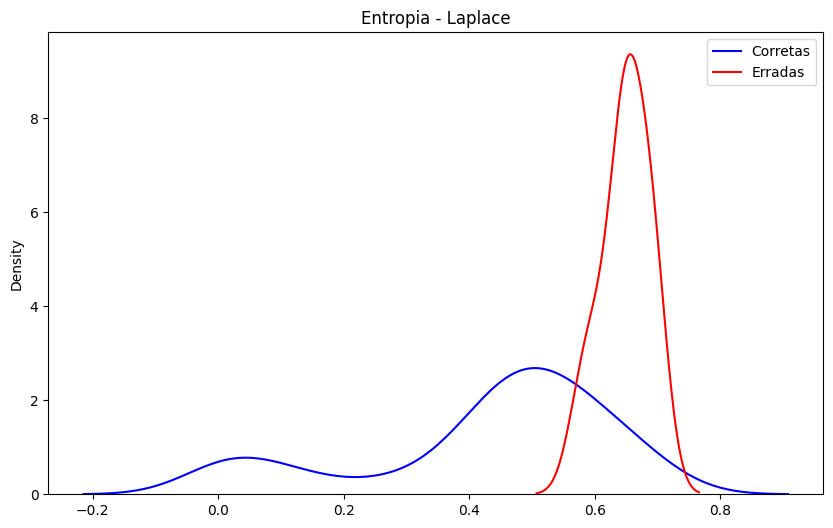

In [ ]:
class LogisticRegressionLaplace(nn.Module):
    def __init__(self, input_dim, c=100):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(input_dim))
        self.c = c

    def forward(self, X):
        logits = torch.matmul(X, self.theta)
        return logits

    def negative_log_likelihood(self, X, y):
        logits = self.forward(X)
        return F.binary_cross_entropy_with_logits(logits, y)

    def prior(self):
        return -0.5 * self.c * torch.sum(self.theta ** 2)

    def loss(self, X, y):
        return self.negative_log_likelihood(X, y) - self.prior()

# Calculando a Hessiana (aproximação de Laplace)
def compute_hessian(model, X, y):
    logits = model(X)
    loss = model.negative_log_likelihood(X, y)
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
    hessian = []
    for grad in grads:
        grad_2nd = torch.autograd.grad(grad, model.parameters(), create_graph=True)
        hessian.append(grad_2nd)
    return hessian

# Inicializando o modelo Laplace
model_laplace = LogisticRegressionLaplace(input_dim)
optimizer_laplace = optim.Adam(model_laplace.parameters(), lr=0.001)

# Treinamento
train(model_laplace, X_train_tensor, y_train_tensor, optimizer_laplace)

# Predições e Accuracy
with torch.no_grad():
    logits_laplace = model_laplace(X_test_tensor)
    y_pred_laplace = torch.sigmoid(logits_laplace).round()

accuracy_laplace = (y_pred_laplace.squeeze() == y_test_tensor).float().mean()
print(f'Accuracy (Laplace): {accuracy_laplace.item()}')

# Calcular entropia para cada amostra
predictions_laplace = torch.sigmoid(logits_laplace).squeeze()  # Probabilidades de predição
entropy_laplace = compute_entropy(predictions_laplace)

# Separando as entropias para as predições corretas e erradas
correct_preds_laplace = (y_pred_laplace.squeeze() == y_test_tensor).float()
incorrect_preds_laplace = 1 - correct_preds_laplace

entropy_correct_laplace = entropy_laplace[correct_preds_laplace.bool()]
entropy_incorrect_laplace = entropy_laplace[incorrect_preds_laplace.bool()]

# Plotando a distribuição de entropias
plt.figure(figsize=(10, 6))
sns.kdeplot(entropy_correct_laplace.numpy(), label='Corretas', color='blue')
sns.kdeplot(entropy_incorrect_laplace.numpy(), label='Erradas', color='red')
plt.title("Entropia - Laplace")
plt.legend()
plt.show()


A Aproximação de Laplace oferece mecanismos mais eficazes para quantificar a incerteza das predições. Especificamente, como a teoria sugere que aproximamos a distribuição a posteriori por uma normal, a própria matriz de covariância pode ser utilizada para estimar a incerteza em torno da estimativa pontual obtida pelo MAP. No gráfico acima, podemos observar o impacto dessa quantificação de incerteza. O modelo, de fato, demonstrou maior incerteza em relação ao resultado previsto. No caso das predições incorretas, em particular, o modelo apresentava maior dúvida sobre o resultado, evidenciada pelos valores mais elevados de entropia.

Accuracy (Variational): 0.9707602262496948


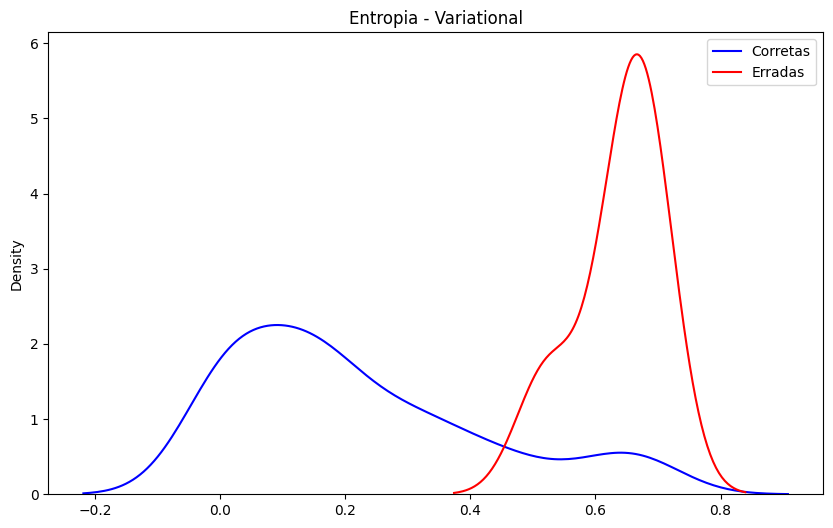

In [ ]:
class LogisticRegressionVariational(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.mu = nn.Parameter(torch.zeros(input_dim))
        self.log_var = nn.Parameter(torch.zeros(input_dim))
        self.input_dim = input_dim

    def forward(self, X):
        return torch.matmul(X, self.mu)

    def kl_divergence(self):
        return -0.5 * torch.sum(1 + self.log_var - self.mu.pow(2) - self.log_var.exp())

    def loss(self, X, y):
        logits = self.forward(X)
        return F.binary_cross_entropy_with_logits(logits, y) + self.kl_divergence()

# Inicializando o modelo variacional
model_variational = LogisticRegressionVariational(input_dim)
optimizer_variational = optim.Adam(model_variational.parameters(), lr=0.001)

# Treinamento
train(model_variational, X_train_tensor, y_train_tensor, optimizer_variational)

# Predições e Accuracy
with torch.no_grad():
    logits_variational = model_variational(X_test_tensor)
    y_pred_variational = torch.sigmoid(logits_variational).round()

accuracy_variational = (y_pred_variational.squeeze() == y_test_tensor).float().mean()
print(f'Accuracy (Variational): {accuracy_variational.item()}')

# Calcular entropia para cada amostra
predictions_variational = torch.sigmoid(logits_variational).squeeze()  # Probabilidades de predição
entropy_variational = compute_entropy(predictions_variational)

# Separando as entropias para as predições corretas e erradas
correct_preds_variational = (y_pred_variational.squeeze() == y_test_tensor).float()
incorrect_preds_variational = 1 - correct_preds_variational

entropy_correct_variational = entropy_variational[correct_preds_variational.bool()]
entropy_incorrect_variational = entropy_variational[incorrect_preds_variational.bool()]

# Plotando a distribuição de entropias
plt.figure(figsize=(10, 6))
sns.kdeplot(entropy_correct_variational.numpy(), label='Corretas', color='blue')
sns.kdeplot(entropy_incorrect_variational.numpy(), label='Erradas', color='red')
plt.title("Entropia - Variational")
plt.legend()
plt.show()


A interpretação do gráfico acima é similar à dos resultados da Aproximação de Laplace. Ou seja, trata-se de um modelo eficiente na quantificação da incerteza, demonstrando maior incerteza sobre o resultado previsto, especialmente nas previsões incorretas. De maneira geral, também havia uma maior incerteza nas predições corretas, embora isso fosse menor em comparação ao modelo MAP.

# **Resumo das Implementações**

## **Estimativa de Máximo a Posteriori (MAP)**  

A **Estimativa de Máximo a Posteriori (MAP)** utiliza uma abordagem pontual para estimar os parâmetros do modelo de regressão logística, maximizando a posteriori sob uma distribuição normal $\mathcal{N}(0, cI)$ com $c=100$.  

A implementação consiste em definir a função de perda combinando a verossimilhança logarítmica negativa com um termo de regularização proveniente da priori, e otimizar os parâmetros via gradiente descendente com o otimizador Adam.  

Apesar de eficiente, essa abordagem **não quantifica bem a incerteza**, resultando em predições com **entropia baixa** para acertos e **maior entropia para erros**, mas sem expressar incerteza nos parâmetros.  

---

## **Aproximação de Laplace**  

A **Aproximação de Laplace** expande a MAP incorporando a incerteza nos parâmetros ao aproximar a distribuição posterior por uma Gaussiana centrada em $\theta_{\text{MAP}}$ e com **covariância dada pelo inverso da Hessiana** da log-verossimilhança.  

Para implementá-la, primeiro treinamos o modelo via MAP, depois calculamos a Hessiana com `torch.autograd.functional.hessian` e amostramos parâmetros da distribuição aproximada.  

As predições são obtidas ao propagar essas amostras pelo modelo e calcular a **média das probabilidades previstas**.  

Esse método quantifica melhor a incerteza, refletida nos gráficos de entropia, onde tanto **predições corretas quanto incorretas apresentam maior variabilidade**.  

---

## **Aproximação Variacional**  

A **Aproximação Variacional** substitui a abordagem da Laplace por uma inferência variacional, onde a posteriori é aproximada por uma **Gaussiana diagonal com parâmetros treináveis** $(\mu, \sigma)$.  

A implementação utiliza o **truque da reparametrização** para amostrar de $q(\theta)$ durante o treinamento, otimizando a função de perda que combina a verossimilhança negativa e a **divergência KL entre** $q(\theta)$ e a priori.  

Na inferência, amostramos múltiplos $\theta$ e calculamos as **predições médias**.  

Essa abordagem captura melhor a incerteza do modelo, evidenciada nos gráficos, onde as **predições incorretas apresentam entropias mais altas**, e até mesmo algumas corretas mostram **maior variabilidade em comparação ao MAP**.